In [1]:
import torch
from torch import nn
import ptwt
import numpy as np
from torch_geometric.nn.conv import GATConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from dataset import WaveletDataset
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
from torchaudio.transforms import PSD
import matplotlib.pyplot as plt
from Model.MENDR.mAtt.optimizer import MixOptimizer
import random
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
train_frac = 0.2
val_frac = 0.001
dataset = WaveletDataset(root="/home/hice1/mchen439/scratch/eegfoundationmodeldata", frac=train_frac + val_frac)
num_train = int(len(dataset) * (train_frac / (train_frac + val_frac)))
num_val = len(dataset) - num_train
train_dataset, val_dataset = torchdata.random_split(dataset, [num_train, num_val])
print("Train and Validation Dataset Length: ", len(train_dataset), len(val_dataset))

Loading 2651 subjects


100%|██████████| 2651/2651 [00:57<00:00, 46.00it/s]

Train and Validation Dataset Length:  25436 128


In [12]:
### Seed ###
torch.cuda.empty_cache()
random.seed(42)
os.environ['PYTHONHASHSEED'] = str(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
## CUDNN ##
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


In [13]:
train_loader = DataLoader(train_dataset, batch_size=1024, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, num_workers=2, shuffle=False)
print(len(train_loader), len(val_loader))

25 1


In [14]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

In [36]:
class WaveletEncoderDecoder(nn.Module):
    def __init__(self, num_channels, conv_kernel_size, conv_kernel_stride, seq_len, heads, encoded_h, decoder_size, decoder_stride, device):
        super(WaveletEncoderDecoder, self).__init__()
        assert len(decoder_size) == len(decoder_stride)
        self.num_channels = num_channels
        self.conv_kernel_size = conv_kernel_size
        self.conv_kernel_stride = conv_kernel_stride
        self.seq_len = seq_len
        self.heads = heads
        self.encoded_h = encoded_h
        self.device = device
        
        self.patch_embedder = nn.Sequential(
            nn.Conv1d(self.num_channels, self.num_channels, 
            self.conv_kernel_size, stride=self.conv_kernel_stride,
            padding=self.conv_kernel_size//2),
            nn.Dropout1d(0.1),
            nn.GroupNorm(1, self.num_channels), # Same as Layer Norm
            nn.GELU()
        ).to(self.device)

        L_out = self.seq_len + 2 * (self.conv_kernel_size//2) - 1 * (self.conv_kernel_size - 1) - 1
        L_out = floor(L_out / self.conv_kernel_stride) + 1

        self.gnn_embedder = GATConv(L_out, self.encoded_h, heads=self.heads, concat=False).to(self.device)
        self.gnn_group_norm = nn.GroupNorm(1, self.num_channels).to(self.device)
        self.gnn_dropout = nn.Dropout(p=0.1).to(self.device)
        self.gnn_gelu = nn.GELU().to(self.device)
        L_out = self.encoded_h
        self.decoders = nn.Sequential()
        for i, (w, s) in enumerate(zip(decoder_size, decoder_stride)):
            if i == len(decoder_size) - 1:
                output_padding = self.seq_len - L_out
                if output_padding + 1 > s:
                    output_padding = -1
                self.decoders.add_module("Decoder_Final".format(i),
                nn.Sequential(
                    nn.ConvTranspose1d(self.num_channels, self.num_channels,
                    w, stride=s, padding=w//2, output_padding=0 if output_padding < 0 else output_padding),
                    nn.Dropout(0.1),
                    nn.GroupNorm(1, self.num_channels),
                    nn.GELU()
                    )
                )
                if output_padding < 0:
                    L_out = (L_out - 1) * s - 2 * (w//2) + 1 * (w - 1) + 1
                    self.decoders.add_module("Decoder_Final_Linear".format(i), nn.Linear(L_out, self.seq_len))
            else:
                self.decoders.add_module("Decoder_{}".format(i),
                nn.Sequential(
                    nn.ConvTranspose1d(self.num_channels, self.num_channels,
                    w, stride=s, padding=w//2),
                    nn.Dropout(0.1),
                    nn.GroupNorm(1, self.num_channels),
                    nn.GELU()
                    )
                )
                L_out = (L_out - 1) * s - 2 * (w//2) + 1 * (w - 1) + 1

        self.decoders = self.decoders.to(self.device)


    def getEncoderParamCount(self):
        patch_embedder_count = sum(p.numel() for p in self.patch_embedder.parameters() if p.requires_grad)
        gnn_embbeder_count = sum(p.numel() for p in self.gnn_embedder.parameters() if p.requires_grad)
        gnn_group_norm_count = sum(p.numel() for p in self.gnn_group_norm.parameters() if p.requires_grad)
        return patch_embedder_count + gnn_embbeder_count + gnn_group_norm_count

    def getDecoderParamCount(self):
        decoder_count = sum(p.numel() for p in self.decoders.parameters() if p.requires_grad)
        return decoder_count

    def forward(self, graph, x):
        patch_embedding = self.patch_embedder(x)

        edge_index = graph.edge_index.to(self.device)
        edge_dist = graph.edge_attr.to(self.device)

        patch_embedding = patch_embedding.view(-1, patch_embedding.shape[-1])

        encoding = self.gnn_embedder(patch_embedding, edge_index, edge_dist)
        encoding = encoding.view(-1, self.num_channels, self.encoded_h)
        encoding = self.gnn_group_norm(encoding)
        encoding = self.gnn_dropout(self.gnn_group_norm(encoding))
        encoding = self.gnn_gelu(encoding)

        decoding = self.decoders(encoding)

        return encoding, decoding



In [37]:
class EncoderDecoder(nn.Module):
    def __init__(self, device):
        super(EncoderDecoder, self).__init__()
        self.device = device
        self.encoder_decoders = nn.ParameterDict({
            'delta': WaveletEncoderDecoder(
                    num_channels = 19,
                    conv_kernel_size = 2,
                    conv_kernel_stride = 2,
                    seq_len = 246,
                    heads = 4,
                    encoded_h = 120,
                    decoder_size = (2, 1),
                    decoder_stride = (2, 1),
                    device = device
                    ),

            'theta': WaveletEncoderDecoder(
                    num_channels = 19,
                    conv_kernel_size = 2,
                    conv_kernel_stride = 2,
                    seq_len = 246,
                    heads = 4,
                    encoded_h = 120,
                    decoder_size = (2, 1),
                    decoder_stride = (2, 1),
                    device = device
                    ),

            'alpha': WaveletEncoderDecoder(
                    num_channels = 19,
                    conv_kernel_size = 4,
                    conv_kernel_stride = 4,
                    seq_len = 486,
                    heads = 4,
                    encoded_h = 240,
                    decoder_size = (2, 2, 1),
                    decoder_stride = (2, 2, 1),
                    device = device 
                    ),

            'beta': WaveletEncoderDecoder(
                    num_channels = 19,
                    conv_kernel_size = 8,
                    conv_kernel_stride = 8,
                    seq_len = 966,
                    heads = 4,
                    encoded_h = 480,
                    decoder_size = (2, 2, 2, 1),
                    decoder_stride = (2, 2, 2, 1),
                    device = device
                    ),

            'gamma': WaveletEncoderDecoder(
                    num_channels = 19,
                    conv_kernel_size = 16,
                    conv_kernel_stride = 16,
                    seq_len = 1925,
                    heads = 4,
                    encoded_h = 960,
                    decoder_size = (2, 2, 2, 1),
                    decoder_stride = (2, 2, 2, 1),
                    device = device
                    ),
        })

    def forward(self, graph, data):
        assert data.keys() == self.encoder_decoders.keys()
        output = {}
        for band, band_decomposition in data.items():
            output[band] = self.encoder_decoders[band](graph, band_decomposition)
        return output
    

In [38]:
def _std_norm(x):
	mean = torch.mean(x, dim=(0, 1), keepdim=True)
	std = torch.std(x, dim=(0, 1), keepdim=True)
	x = (x - mean) / std
	return x

In [39]:
model = EncoderDecoder(device).to(device)
optimizer = MixOptimizer(torch.optim.Adam(model.parameters(), lr=1e-2))
loss_fn = nn.MSELoss()
print("Total parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Total parameters: 20009882


In [40]:
def fft_loss(output, target):
    output_fft = torch.fft.fft(output, dim=-1)
    output_amplitude = torch.abs(output_fft)
    output_angle = torch.angle(output_fft)

    target_fft = torch.fft.fft(target, dim=-1)
    target_amplitude = torch.abs(target_fft)
    target_angle = torch.abs(target_fft)

    return (loss_fn(output_amplitude, target_amplitude) + (loss_fn(output_angle, target_angle))) * 1e-2

In [41]:
def train_one_epoch(model, optimizer, loss_fn, train_loader):
	loss_sum = 0
	model.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]

		relevant_bands = [_std_norm(x) for x in relevant_bands]

		batch_size = data['delta'].shape[0]

		inputs = dict(zip(BANDS, relevant_bands))

		optimizer.zero_grad()

		outputs = model(data['graph'], inputs)

		delta_loss = loss_fn(inputs['delta'], outputs['delta'][1]) + fft_loss(inputs['delta'], outputs['delta'][1]) 
		theta_loss = loss_fn(inputs['theta'], outputs['theta'][1])  + fft_loss(inputs['theta'], outputs['theta'][1])
		alpha_loss = loss_fn(inputs['alpha'], outputs['alpha'][1])  + fft_loss(inputs['alpha'], outputs['alpha'][1])
		beta_loss =  loss_fn(inputs['beta'],  outputs['beta'][1])  + fft_loss(inputs['beta'], outputs['beta'][1])
		gamma_loss = loss_fn(inputs['gamma'], outputs['gamma'][1])  + fft_loss(inputs['gamma'], outputs['gamma'][1])

		loss = delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		loss.backward()
		optimizer.step()
		loss_sum += loss.item()

		pbar.set_postfix(loss=loss.item(),
			delta_loss=delta_loss.item(),
			theta_loss=theta_loss.item(),
			alpha_loss=alpha_loss.item(),
			beta_loss=beta_loss.item(),
			gamma_loss=gamma_loss.item())

	return loss_sum

In [45]:
def validate_one_epoch(model, loss_fn, val_loader):
	loss_sum = 0
	model.eval()

	pbar = tqdm.trange(len(val_loader), desc="Validating")
	data_iterator = iter(val_loader)

	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]

		relevant_bands = [_std_norm(x) for x in relevant_bands]

		batch_size = data['delta'].shape[0]

		inputs = dict(zip(BANDS, relevant_bands))

		optimizer.zero_grad()

		outputs = model(data['graph'], inputs)

		delta_loss = loss_fn(inputs['delta'], outputs['delta'][1]) + fft_loss(inputs['delta'], outputs['delta'][1])
		theta_loss = loss_fn(inputs['theta'], outputs['theta'][1])  + fft_loss(inputs['theta'], outputs['theta'][1])
		alpha_loss = loss_fn(inputs['alpha'], outputs['alpha'][1])  + fft_loss(inputs['alpha'], outputs['alpha'][1])
		beta_loss =  loss_fn(inputs['beta'],  outputs['beta'][1])  + fft_loss(inputs['beta'], outputs['beta'][1])
		gamma_loss = loss_fn(inputs['gamma'], outputs['gamma'][1])  + fft_loss(inputs['gamma'], outputs['gamma'][1])

		loss = delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		loss_sum += loss.item()

		pbar.set_postfix(loss=loss.item(),
			delta_loss=delta_loss.item(),
			theta_loss=theta_loss.item(),
			alpha_loss=alpha_loss.item(),
			beta_loss=beta_loss.item(),
			gamma_loss=gamma_loss.item())

	return loss_sum

In [46]:
for epoch_idx in range(30):
	training_loss = train_one_epoch(model, optimizer, loss_fn, train_loader)
	val_loss = validate_one_epoch(model, loss_fn, val_loader)
	optimizer.scheduler_step(val_loss)
	print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss, "Total Validation Loss: ", val_loss)
	#print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss)

Validating: 100%|██████████| 1/1 [00:00<00:00,  1.55it/s, alpha_loss=5.22, beta_loss=15.8, delta_loss=3.12, gamma_loss=63.1, loss=90.3, theta_loss=3.05]


Epoch:  0 Total Training Loss:  23701.483810424805 Total Validation Loss:  90.25959014892578


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.54it/s, alpha_loss=5.03, beta_loss=9.35, delta_loss=3.19, gamma_loss=18.9, loss=39.4, theta_loss=2.88]


Epoch:  1 Total Training Loss:  1415.5878677368164 Total Validation Loss:  39.374576568603516


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.63it/s, alpha_loss=5.01, beta_loss=9.23, delta_loss=3.13, gamma_loss=18, loss=38.3, theta_loss=2.87]


...

Epoch:  27 Total Training Loss:  981.2873954772949 Total Validation Loss:  35.61060333251953


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.51it/s, alpha_loss=4.43, beta_loss=8.05, delta_loss=2.98, gamma_loss=17.4, loss=35.8, theta_loss=2.85]


Epoch:  28 Total Training Loss:  972.7741241455078 Total Validation Loss:  35.76214599609375


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.48it/s, alpha_loss=4.43, beta_loss=8.09, delta_loss=2.97, gamma_loss=17.3, loss=35.6, theta_loss=2.85]


Epoch:  29 Total Training Loss:  975.4326248168945 Total Validation Loss:  35.61888122558594


In [92]:
torch.save(model.state_dict, "/home/hice1/mchen439/scratch/models/MENDREncoder3.pt")

In [47]:
model.eval()

for data in val_loader:
    relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]
    
    relevant_bands = [_std_norm(x) for x in relevant_bands]


    batch_size = data['delta'].shape[0]

    inputs = dict(zip(BANDS, relevant_bands))

    optimizer.zero_grad()

    outputs = model(data['graph'], inputs)
    
    print(inputs['delta'].shape, outputs['delta'][1].shape)

torch.Size([128, 19, 246]) torch.Size([128, 19, 246])


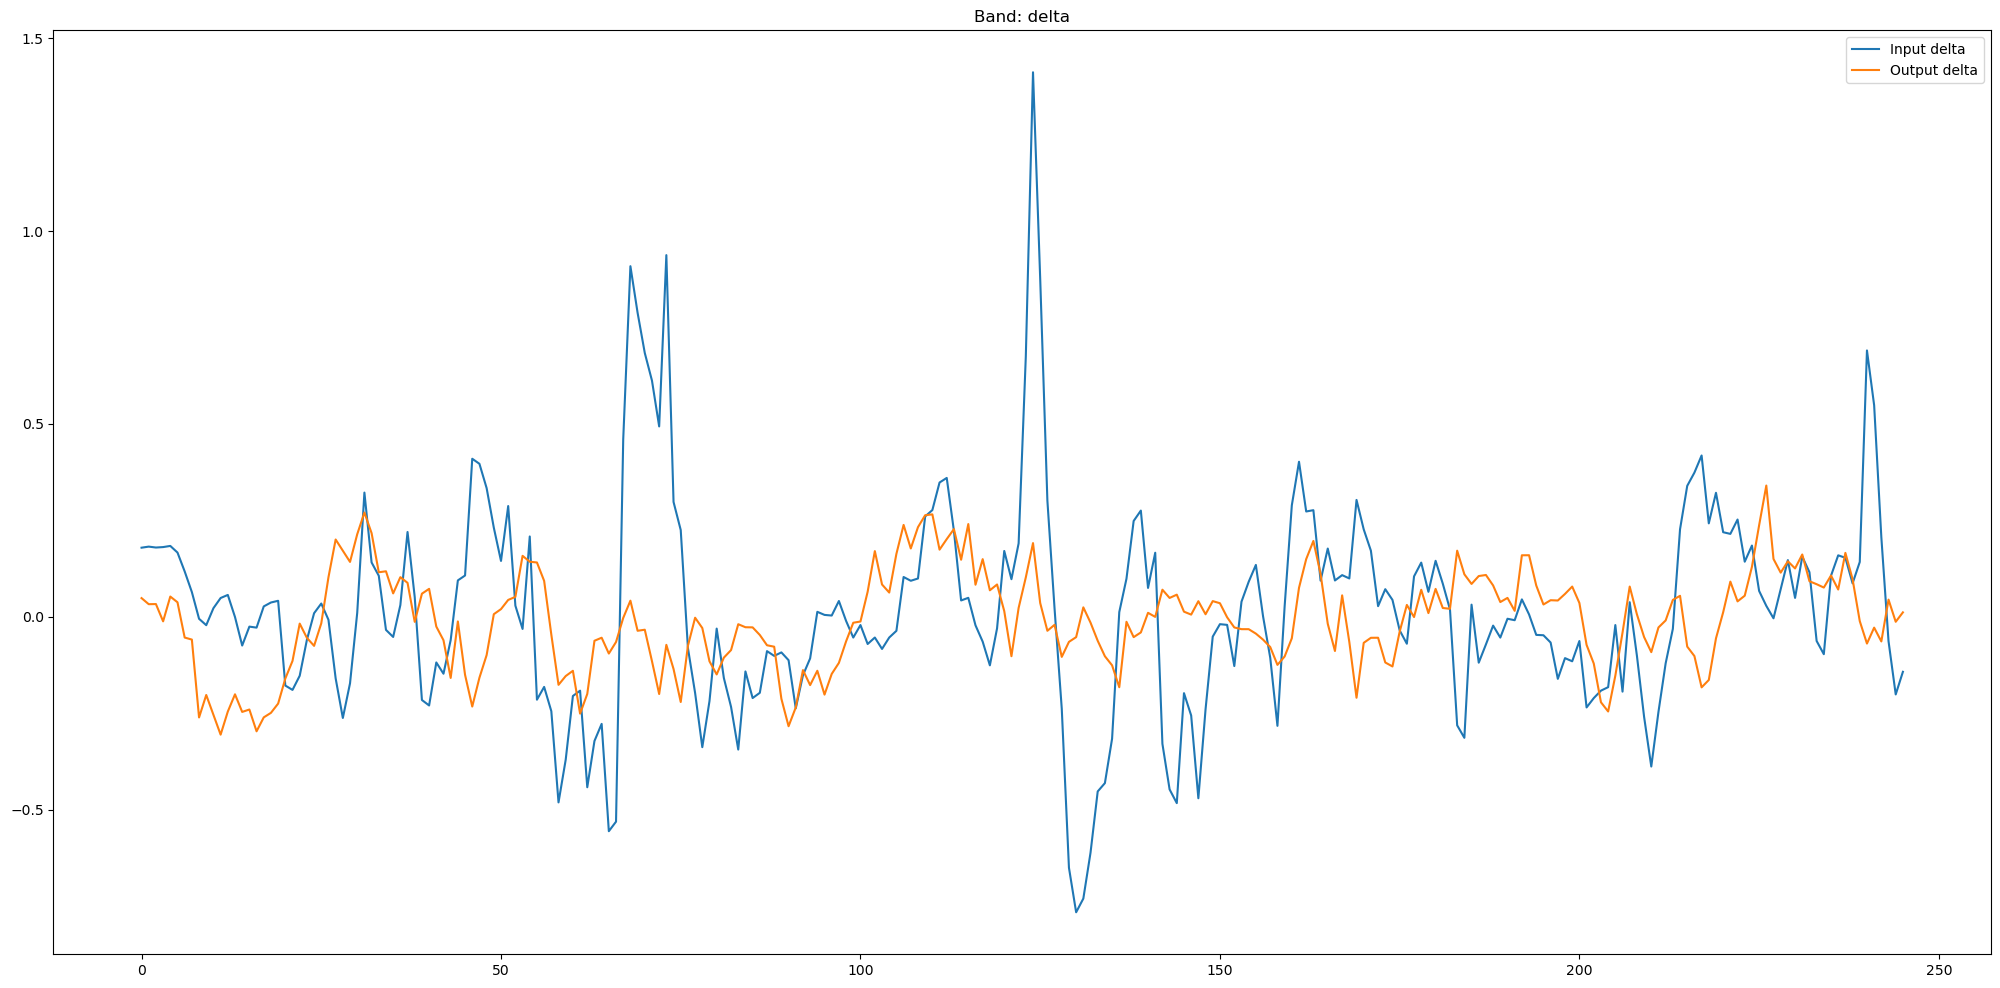

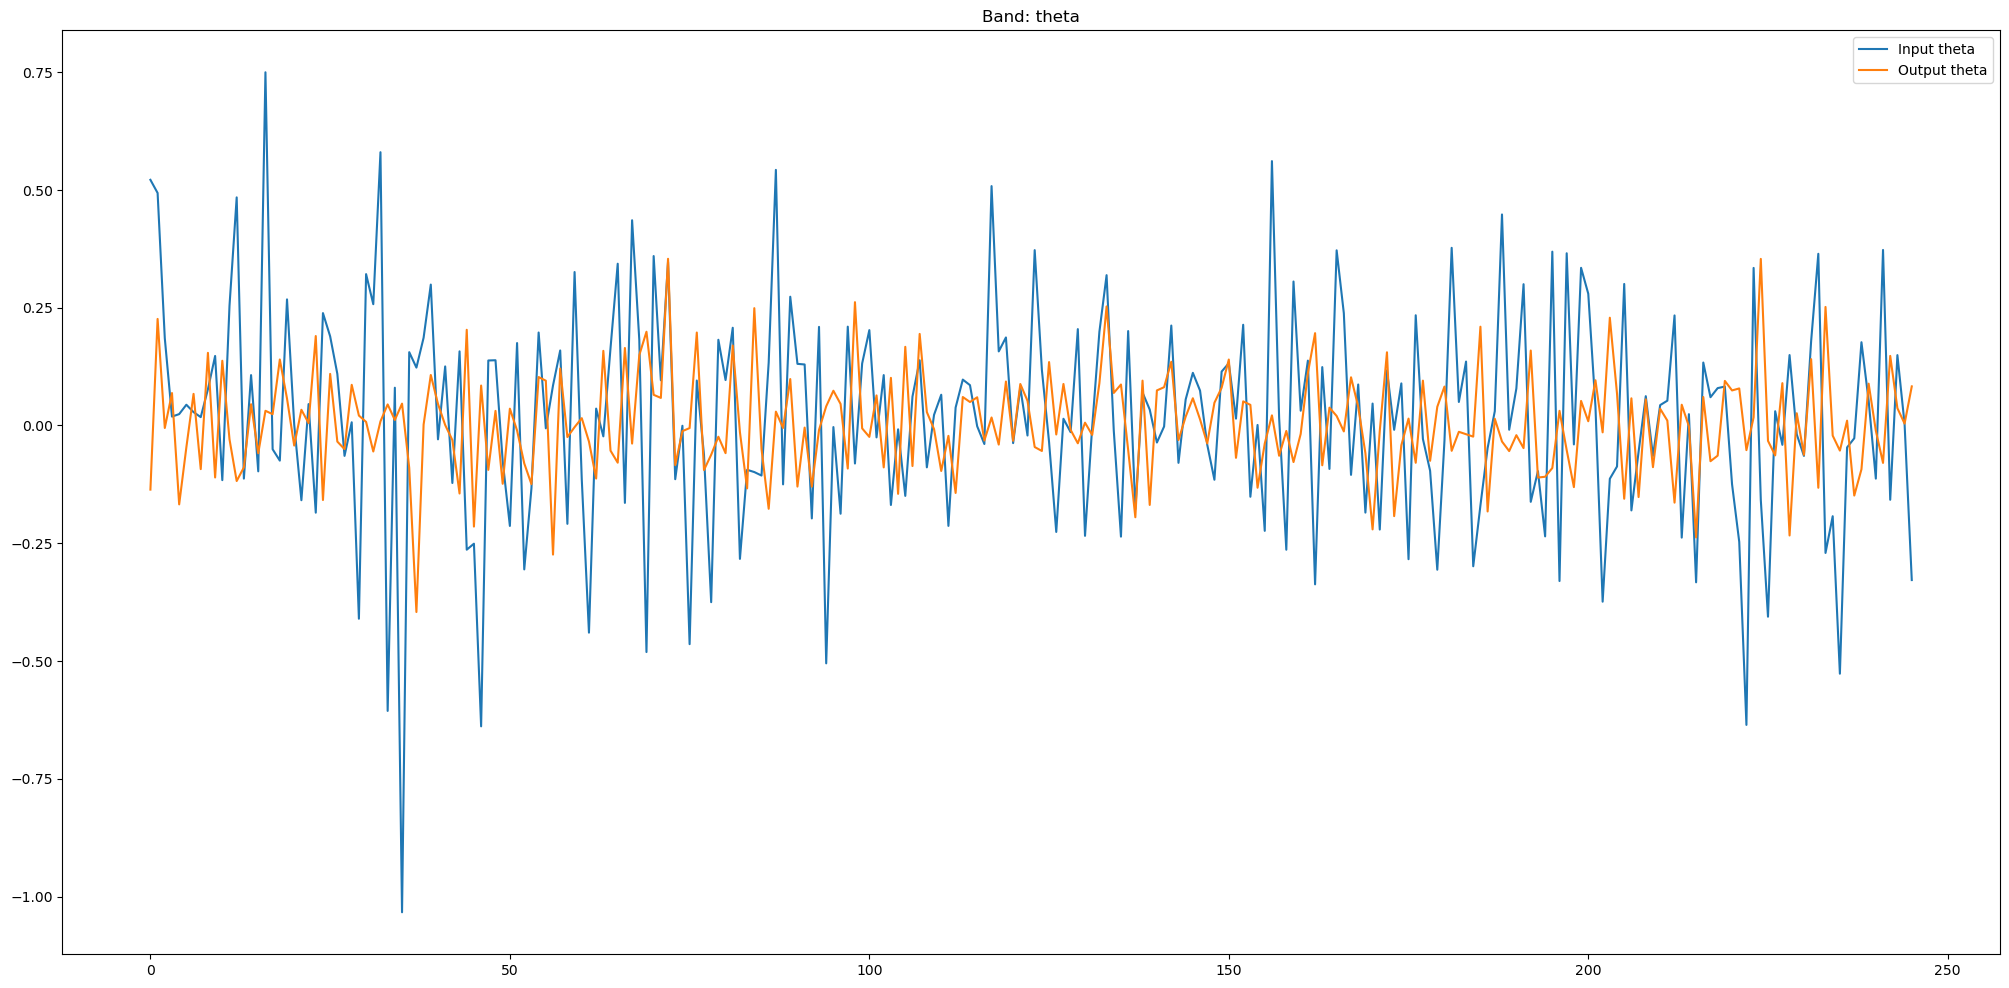

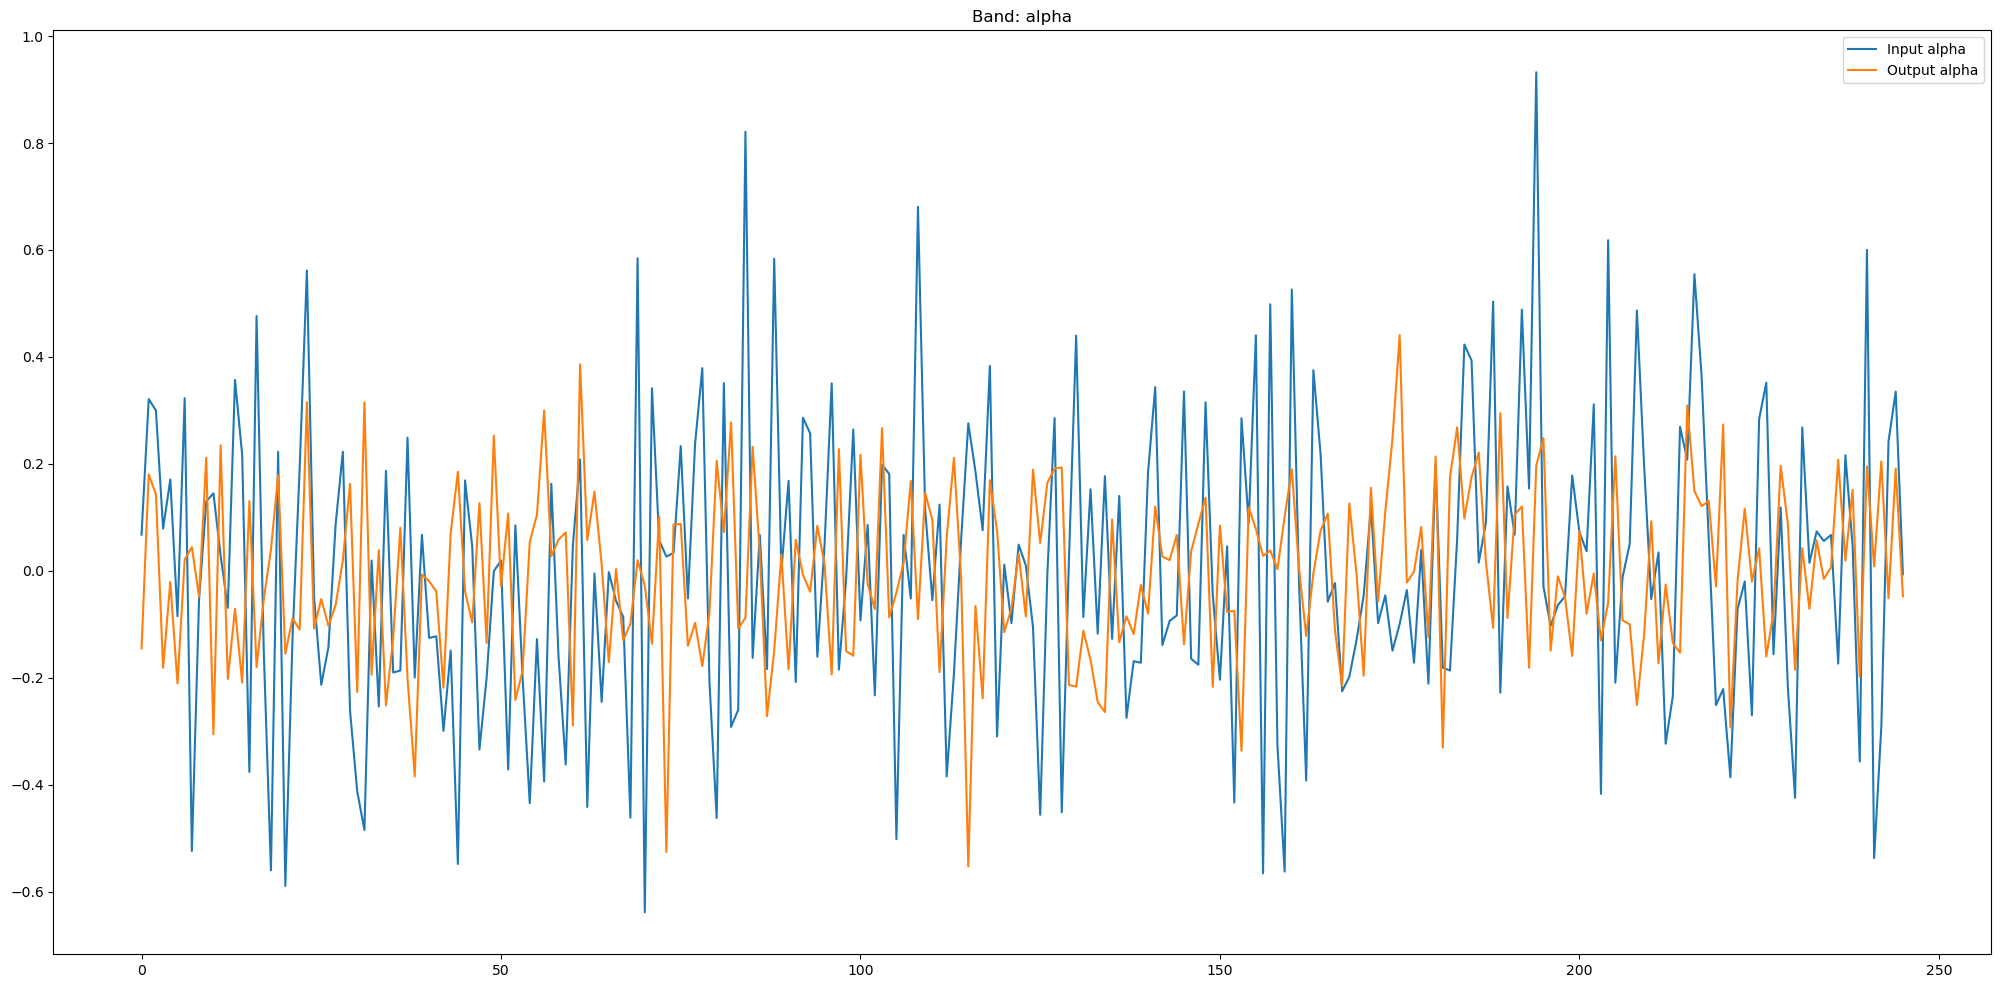

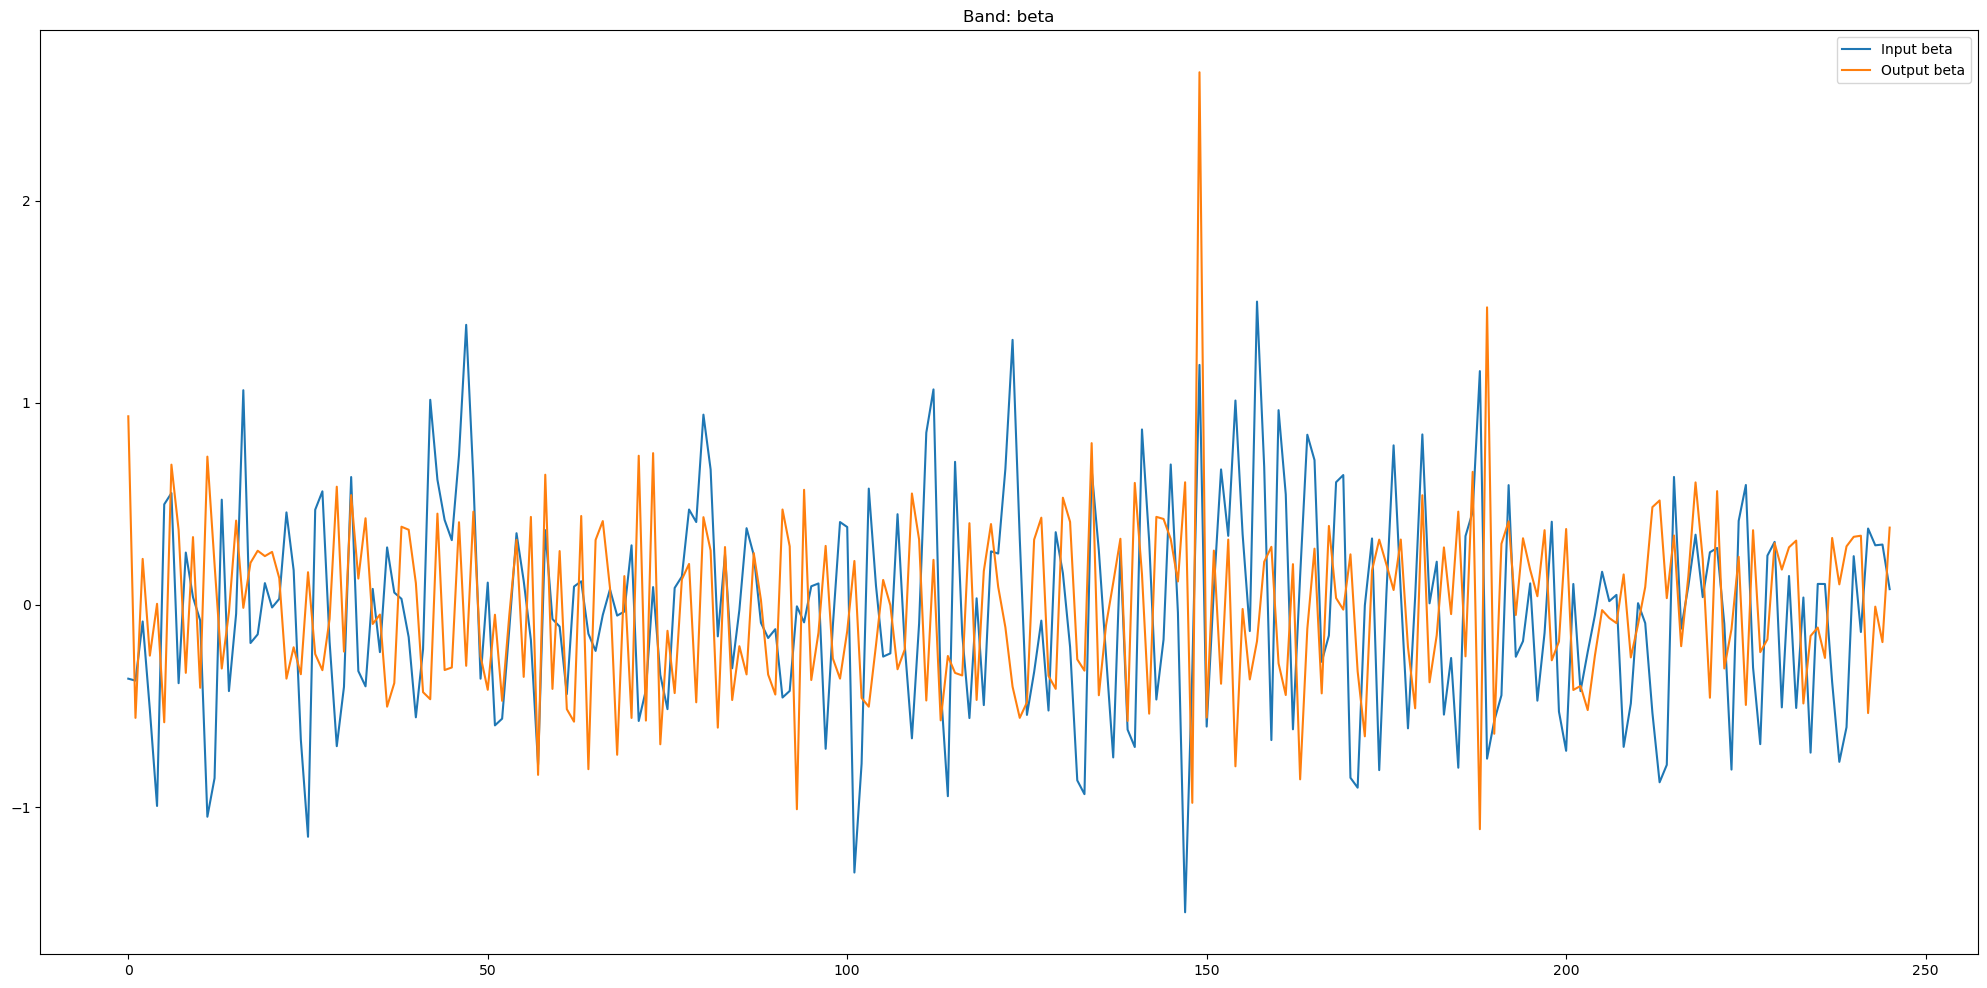

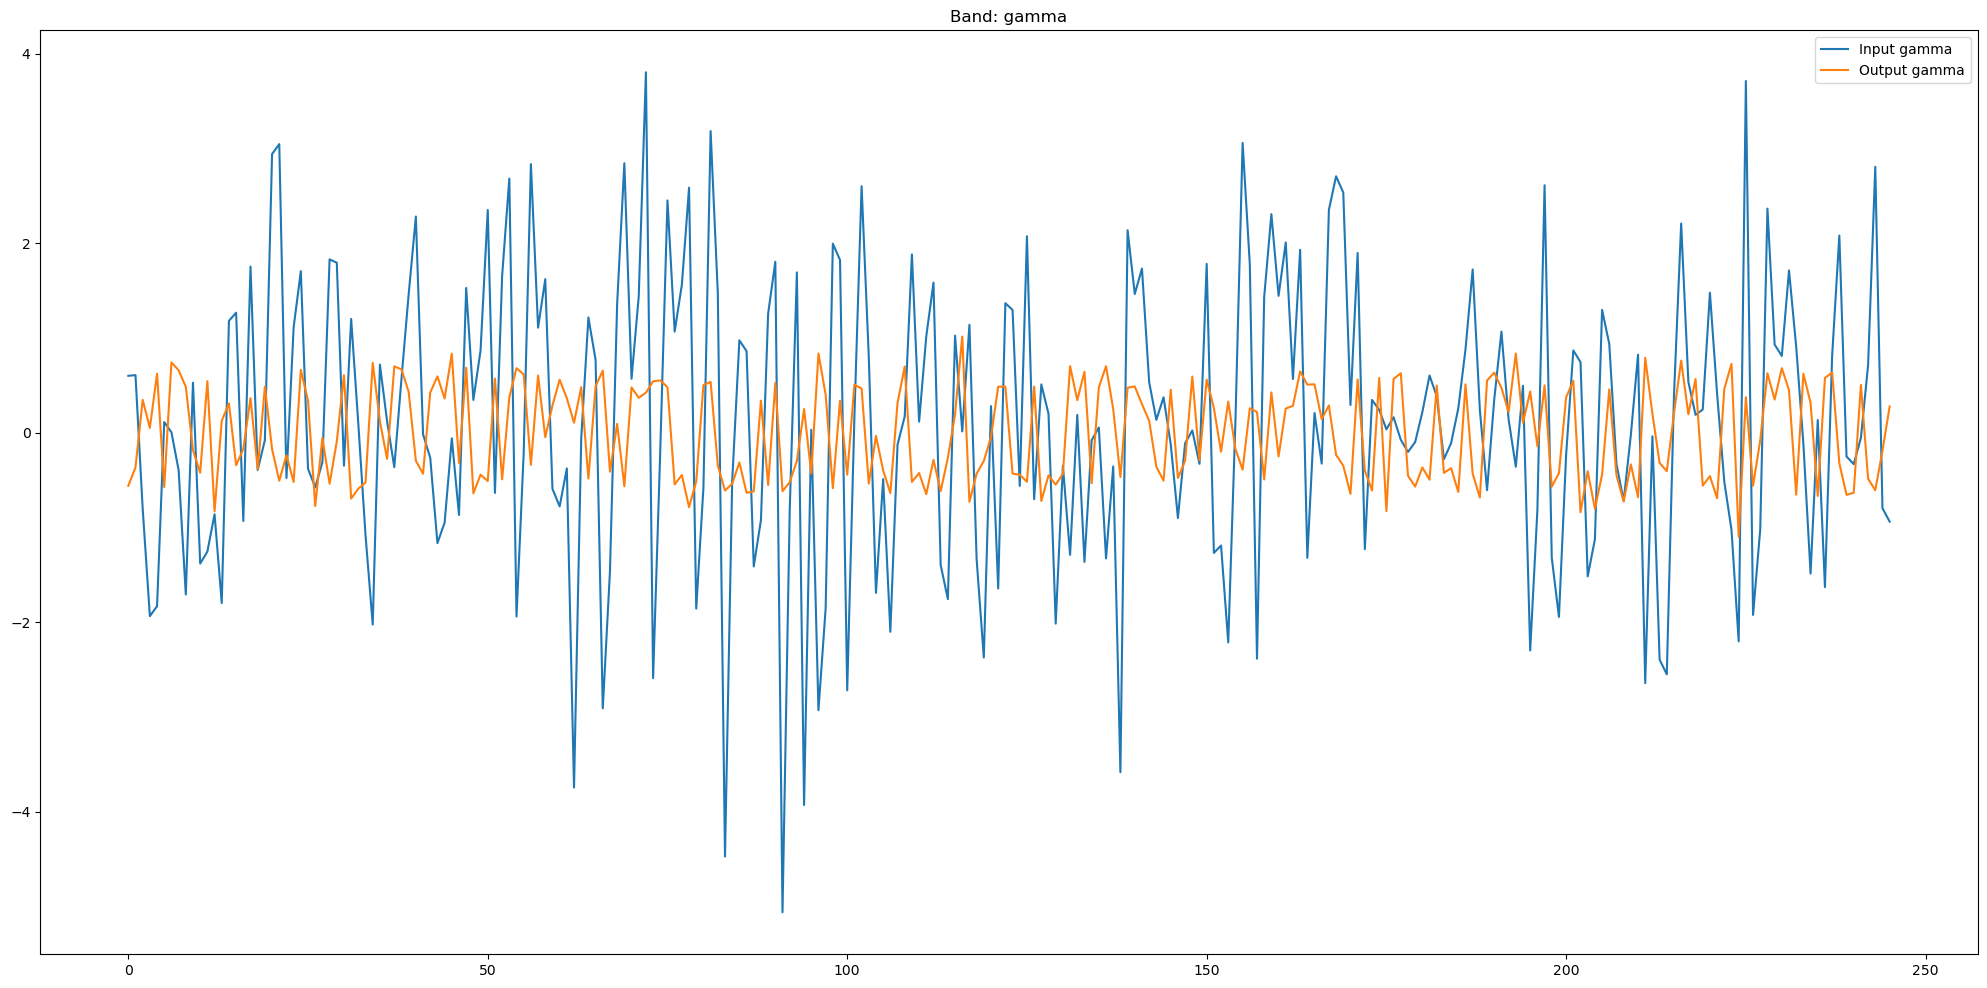

In [53]:
channel = 3
for band in ['delta', 'theta', 'alpha', 'beta', 'gamma']:
    plt.figure(figsize=(25, 12))
    plt.plot(inputs[band][3, channel, :246].cpu().detach().numpy(), label=f"Input {band}")
    plt.plot(outputs[band][1][3, channel, :246].cpu().detach().numpy(), label=f"Output {band}")
    plt.title(f"Band: {band}")
    plt.legend()
    plt.show()